# 🧠 Notebook 3: LSTM Deep Learning Forecast
### StockSense AI — Sequence Modeling with Keras

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.21.0


## 1. Load & Scale Data

In [8]:
print(df.columns.tolist())
print(df[['Close']].head())
print(df[['Close']].dtypes)
print(df[['Close']].dropna().shape)

['Open', 'High', 'Low', 'Close', 'Volume', 'MA_20', 'MA_50', 'MA_200', 'RSI', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'BB_Mid']
                         Close
Price                         
Ticker                    AAPL
Date                       NaN
2018-10-16   52.57398223876953
2018-10-17   52.34678649902344
2018-10-18  51.123260498046875
Close    object
dtype: object
(1562, 1)


In [10]:
# Force all columns to numeric, coerce errors to NaN
df = df.apply(pd.to_numeric, errors='coerce')

# Flatten MultiIndex if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.loc[:, ~df.columns.duplicated()]

features = ['Close', 'Volume', 'RSI', 'MACD', 'MA_20']
data = df[features].dropna().values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

close_scaler = MinMaxScaler()
close_scaled = close_scaler.fit_transform(df[['Close']].dropna())

print(f'Data shape: {data_scaled.shape}')
print(f'Features: {features}')

Data shape: (1561, 5)
Features: ['Close', 'Volume', 'RSI', 'MACD', 'MA_20']


## 2. Build Sequences

In [11]:
def make_sequences(data, lookback, close_col=0):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, close_col])  # predict Close
    return np.array(X), np.array(y)

X, y = make_sequences(data_scaled, LOOKBACK)

# Train / test split
SPLIT = int(len(X) * 0.85)
X_train, X_test = X[:SPLIT], X[SPLIT:]
y_train, y_test = y[:SPLIT], y[SPLIT:]

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

X_train: (1275, 60, 5)  |  X_test: (226, 60, 5)


## 3. Build LSTM Model

In [12]:
tf.random.set_seed(42)

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, len(features))),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,489 (513.63 KB)

 Trainable params: 131,233 (512.63 KB)

 Non-trainable params: 256 (1.00 KB)

## 4. Train

In [13]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0287 - mae: 0.1166 - val_loss: 0.1026 - val_mae: 0.3188 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0079 - mae: 0.0687 - val_loss: 0.1128 - val_mae: 0.3345 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0058 - mae: 0.0596 - val_loss: 0.1023 - val_mae: 0.3183 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0050 - mae: 0.0553 - val_loss: 0.0899 - val_mae: 0.2981 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0040 - mae: 0.0486 - val_loss: 0.0863 - val_mae: 0.2923 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0040 - mae: 0.0487 - val_loss: 0.0732 - val_mae: 0.2688 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0033 - mae: 0.0448 - val_loss: 0.0704 - val_mae: 0.2638 - learning_rate: 0.0010
Epoch 

## 5. Training Loss Curve

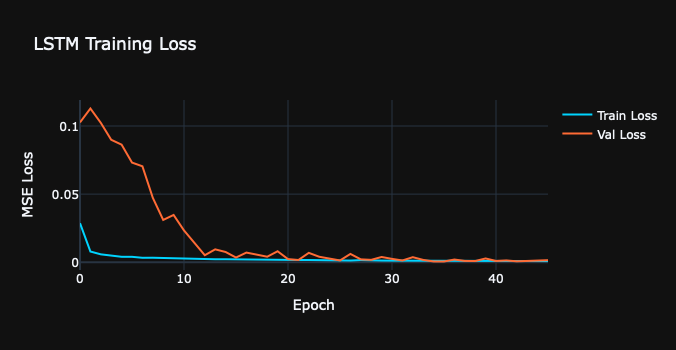

In [14]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=history.history['loss'],     name='Train Loss', line=dict(color='#00d4ff')))
fig.add_trace(go.Scatter(y=history.history['val_loss'], name='Val Loss',   line=dict(color='#ff6b35')))
fig.update_layout(title='LSTM Training Loss', template='plotly_dark',
    xaxis_title='Epoch', yaxis_title='MSE Loss', height=350)
fig.show()

## 6. Evaluate on Test Set

In [15]:
y_pred_scaled = model.predict(X_test)

# Inverse transform (Close column only)
y_pred = close_scaler.inverse_transform(y_pred_scaled)
y_true = close_scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'LSTM Results')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
LSTM Results
  RMSE : 25.7441
  MAE  : 20.8030
  MAPE : 9.28%


## 7. Prediction Plot

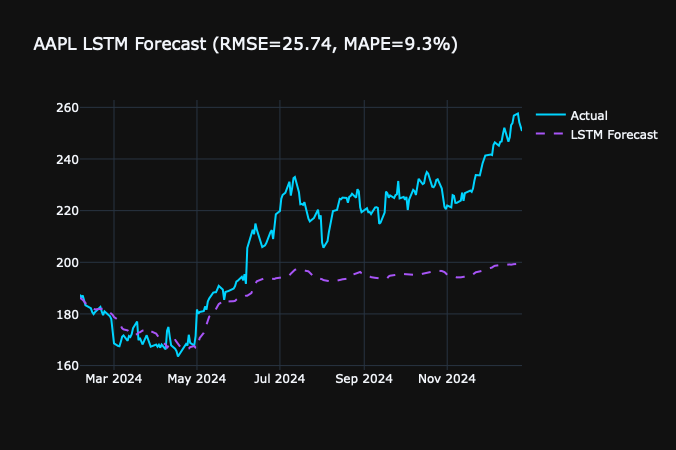

In [16]:
dates = df.index[LOOKBACK + SPLIT:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=dates, y=y_true.flatten(), name='Actual', line=dict(color='#00d4ff')))
fig.add_trace(go.Scatter(x=dates, y=y_pred.flatten(), name='LSTM Forecast',
    line=dict(color='#a855f7', dash='dash')))
fig.update_layout(title=f'{TICKER} LSTM Forecast (RMSE={rmse:.2f}, MAPE={mape:.1f}%)',
    template='plotly_dark', height=450)
fig.show()

## 8. Save Model & Scaler

In [17]:
import joblib
model.save(f'../models/saved_models/{TICKER}_lstm.h5')
joblib.dump(scaler, f'../models/saved_models/{TICKER}_scaler.pkl')
joblib.dump(close_scaler, f'../models/saved_models/{TICKER}_close_scaler.pkl')
print('✅ LSTM model and scalers saved')

✅ LSTM model and scalers saved
